In [ ]:
# 【problem1】Hypothetical function

In [1]:
import numpy as np

class ScratchLinearRegression:
    """
    Scratch implementation of linear regression
    ... (omitted for brevity)
    """

    def __init__(self, num_iter, lr, no_bias, verbose):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        # Initialize self.coef_ (The actual initialization is usually done in the fit method, but we initialize it for the sake of the _linear_hypothesis function)
        # For demonstration, we'll assume it's initialized before _linear_hypothesis is called.
        self.coef_ = None # Will be initialized in fit

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn linear regression.
        ... (omitted for brevity)
        """
        # --- Placeholder for initialization of self.coef_ and bias augmentation ---
        n_samples, n_features = X.shape
        if not self.no_bias:
            # Augment X with a column of ones for the bias term
            X_b = np.hstack([np.ones((n_samples, 1)), X])
            self.coef_ = np.random.randn(n_features + 1, 1) # Initialize parameters including bias
        else:
            X_b = X
            self.coef_ = np.random.randn(n_features, 1) # Initialize parameters without bias
        
        # NOTE: In a complete implementation, this would be inside the iteration loop.
        # We'll use X_b internally in the fit and _linear_hypothesis methods for consistency.
        
        for i in range(self.iter):
            # 1. Compute prediction (using _linear_hypothesis)
            y_pred = self._linear_hypothesis(X_b) 
            
            # 2. Compute the error
            error = y_pred - y.reshape(-1, 1)
            
            # 3. Compute the gradient of the loss function (MSE)
            # Gradient: (1/m) * X_b.T * error
            gradient = (1/n_samples) * X_b.T @ error 
            
            # 4. Update parameters
            self.coef_ = self.coef_ - self.lr * gradient
            
            # 5. Compute and record loss (not fully shown)
            # self.loss[i] = self._mse(y.reshape(-1, 1), y_pred)
            # if X_val is not None:
            #     # Compute validation loss
            #     X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val]) if not self.no_bias else X_val
            #     y_val_pred = self._linear_hypothesis(X_val_b)
            #     self.val_loss[i] = self._mse(y_val.reshape(-1, 1), y_val_pred)
            
            if self.verbose and i % 100 == 0:
                 # print(f"Iteration {i}: Loss = {self.loss[i]}")
                 pass # Placeholder print
        
        pass

    def predict(self, X):
        """
        Estimate using linear regression.
        """
        # Augment X with bias term if necessary, just like in fit
        if not self.no_bias:
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        # Use the hypothetical function
        prediction = self._linear_hypothesis(X_b)
        return prediction.flatten() # Return a 1D array

    def _linear_hypothesis(self, X):
        """
        Compute a linear hypothetical function.
        
        Parameters
        ----------
        X : ndarray, shape(n_samples, n_features_with_or_without_bias)
            Training data (or validation/test data), **assumed to be augmented with ones if bias is used.**

        Returns
        -------
        ndarray, shape(n_samples, 1)
            Estimated result by linear hypothetical function
        """
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized. Call fit() first.")
            
        # The linear hypothesis in vector form is h(x) = X @ theta, where @ is the matrix multiplication operator.
        # X is (n_samples, n_features), self.coef_ is (n_features, 1)
        # Result is (n_samples, 1)
        
        # We use the matrix multiplication operator '@' for clarity and efficiency.
        # np.dot(X, self.coef_) works too.
        
        # Ensure self.coef_ is the correct shape, e.g., (n_features, 1) for matrix multiplication.
        # We assume self.coef_ is initialized as (n_features, 1) in fit.
        
        return X @ self.coef_

    # def _mse(self, y_true, y_pred):
    #     """Mean Squared Error loss function (optional helper)"""
    #     m = len(y_true)
    #     return (1/(2*m)) * np.sum((y_pred - y_true)**2)

In [ ]:
# 【problem2】Steepest descent

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

class ScratchLinearRegression:
    """
    Scratch implementation of linear regression using Batch Gradient Descent.

    Parameters
    ----------
    num_iter : int
      Number of iterations (epochs)
    lr : float
      Learning rate (alpha)
    no_bias : bool
      True if no bias term is included (model passes through origin)
    verbose : bool
      True to output the learning process details

    Attributes
    ----------
    self.coef_ : ndarray, shape (n_features, 1) or (n_features + 1, 1)
      Parameters (weights), including the bias term if no_bias is False.
    self.loss : ndarray, shape (self.iter,)
      Record losses on training data for each iteration.
    self.val_loss : ndarray, shape (self.iter,)
      Record loss on validation data for each iteration.
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        """
        Compute the linear hypothetical function: h_theta(X) = X @ theta

        Parameters
        ----------
        X: ndarray, shape (n_samples, n_features)
            Training data (must already be augmented with ones if bias is used).

        Returns
        -------
        ndarray, shape (n_samples, 1)
            Estimated result by linear hypothetical function.
        """
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized. Call fit() first.")

        # Matrix multiplication: (n_samples, n_features) @ (n_features, 1) = (n_samples, 1)
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        Calculates the Mean Squared Error (MSE) loss J(theta).
        
        The cost function J(theta) is defined as: (1/(2m)) * sum((h_theta(x) - y)^2)
        
        Parameters
        ----------
        y_true : ndarray, shape(n_samples, 1)
            True target values.
        y_pred : ndarray, shape(n_samples, 1)
            Predicted values.
            
        Returns
        -------
        float
            The MSE loss value.
        """
        m = len(y_true)
        # We use (1/(2*m)) which is standard practice in machine learning for cleaner gradient derivation
        return (1/(2*m)) * np.sum((y_pred - y_true)**2)
    
    def _gradient_descent(self, X, error):
        """
        Updates the parameters (self.coef_) using the steepest descent method.
        
        The update rule is: theta := theta - alpha * (1/m) * X.T @ error

        Parameters
        ----------
        X : ndarray, shape(n_samples, n_features)
            Feature matrix (augmented with bias column if no_bias=False).
        error : ndarray, shape(n_samples, 1)
            The difference between predicted and true values: (h_theta(X) - y).
        """
        # Number of samples (m)
        m = X.shape[0]

        # Calculate the gradient vector: (1/m) * X.T @ error
        # X.T is (n_features, m). error is (m, 1). Result is gradient (n_features, 1).
        gradient = (1/m) * X.T @ error

        # Update parameters: theta = theta - learning_rate * gradient
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn linear regression using Batch Gradient Descent.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Features of training data.
        y : ndarray, shape (n_samples, )
            Correct answer value of training data.
        X_val : ndarray, shape (n_samples, n_features)
            Features of verification data.
        y_val : ndarray, shape (n_samples, )
            Correct value of verification data.
        """
        # 1. Data Preprocessing: Handle Bias Term and Reshape y
        n_samples, n_features = X.shape
        # Ensure y is a column vector (m, 1) for matrix operations
        y_train = y.reshape(-1, 1) 

        if not self.no_bias:
            # Augment X with a column of ones for the bias term (x0=1)
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            # Initialize parameters including bias: (n_features + 1, 1)
            # Use small random initialization to avoid large initial gradients
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            # Initialize parameters without bias: (n_features, 1)
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        # Prepare validation data if provided
        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                # Augment validation features with ones
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print("\n--- Starting Linear Regression Training ---")

        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            # Compute the prediction (Hypothesis)
            y_pred = self._linear_hypothesis(X_train) 
            
            # Compute the error vector: (h_theta(X) - y)
            error = y_pred - y_train
            
            # Perform Gradient Descent (Update self.coef_) - PROBLEM 2
            self._gradient_descent(X_train, error)
            
            # Compute and record training loss
            self.loss[i] = self._mse(y_train, y_pred)
            
            # Compute and record validation loss (if data available)
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output (print every 10% of iterations)
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.4f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.4f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        """
        Estimate using linear regression.
        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample
        Returns
        -------
            ndarray, shape (n_samples,)
            Estimated result by linear regression (1D array).
        """
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
            
        # Augment X with bias term if necessary
        if not self.no_bias:
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        # Use the hypothetical function
        prediction = self._linear_hypothesis(X_b)
        # Return a 1D array as is common for prediction outputs
        return prediction.flatten()

# --- DEMONSTRATION OF USAGE ---

# 1. Generate synthetic data for testing
np.random.seed(42)
# True relationship: y = 3 * x + 5 + noise
X_data = 2 * np.random.rand(100, 1) 
y_data = 5 + 3 * X_data + np.random.randn(100, 1) 
y_data = y_data.flatten() # Ensure y is (n_samples,)

# 2. Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 3. Instantiate and train the model
model = ScratchLinearRegression(num_iter=1000, lr=0.01, no_bias=False, verbose=True)
model.fit(X_train, y_train, X_val, y_val)

# 4. Make predictions
y_pred_scratch = model.predict(X_val)

# 5. Evaluate results
mse = mean_squared_error(y_val, y_pred_scratch)

print(f"--- Model Evaluation ---")
# The first element of coef_ is the bias (theta_0), the second is the weight (theta_1)
if not model.no_bias:
    print(f"Learned Bias (theta_0): {model.coef_[0, 0]:.4f}")
    print(f"Learned Weight (theta_1): {model.coef_[1, 0]:.4f}")
else:
    print(f"Learned Weight (theta_1): {model.coef_[0, 0]:.4f}")

print(f"Final Validation MSE (using sklearn): {mse:.4f}")
print(f"Final Validation Loss (from model record): {model.val_loss[-1]:.4f} (Note: This is J(theta) = MSE/2)")


# 6. Plotting the loss history (requires matplotlib but shown for completeness)
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 5))
# plt.plot(model.loss, label='Training Loss')
# plt.plot(model.val_loss, label='Validation Loss')
# plt.title('Loss History')
# plt.xlabel('Iteration')
# plt.ylabel('J(theta) (MSE/2)')
# plt.legend()
# plt.grid(True)
# plt.show()



--- Starting Linear Regression Training ---
Iteration 0/1000: Train Loss: 31.7698, Val Loss: 32.6073
Iteration 100/1000: Train Loss: 1.1505, Val Loss: 1.3130
Iteration 200/1000: Train Loss: 0.5999, Val Loss: 0.6283
Iteration 300/1000: Train Loss: 0.5448, Val Loss: 0.5389
Iteration 400/1000: Train Loss: 0.5106, Val Loss: 0.4872
Iteration 500/1000: Train Loss: 0.4861, Val Loss: 0.4499
Iteration 600/1000: Train Loss: 0.4686, Val Loss: 0.4220
Iteration 700/1000: Train Loss: 0.4560, Val Loss: 0.4010
Iteration 800/1000: Train Loss: 0.4469, Val Loss: 0.3850
Iteration 900/1000: Train Loss: 0.4404, Val Loss: 0.3728
--- Training Complete ---

--- Model Evaluation ---
Learned Bias (theta_0): 4.8599
Learned Weight (theta_1): 3.0516
Final Validation MSE (using sklearn): 0.7268
Final Validation Loss (from model record): 0.3634 (Note: This is J(theta) = MSE/2)


In [ ]:
# 【problem 3】Estimated

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

class ScratchLinearRegression:
    """
    Scratch implementation of linear regression using Batch Gradient Descent.

    Parameters
    ----------
    num_iter : int
      Number of iterations (epochs)
    lr : float
      Learning rate (alpha)
    no_bias : bool
      True if no bias term is included (model passes through origin)
    verbose : bool
      True to output the learning process details

    Attributes
    ----------
    self.coef_ : ndarray, shape (n_features, 1) or (n_features + 1, 1)
      Parameters (weights), including the bias term if no_bias is False.
    self.loss : ndarray, shape (self.iter,)
      Record losses on training data for each iteration.
    self.val_loss : ndarray, shape (self.iter,)
      Record loss on validation data for each iteration.
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        """
        [Problem 1] Compute the linear hypothetical function: h_theta(X) = X @ theta

        Parameters
        ----------
        X: ndarray, shape (n_samples, n_features)
            Training data (must already be augmented with ones if bias is used).

        Returns
        -------
        ndarray, shape (n_samples, 1)
            Estimated result by linear hypothetical function.
        """
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized. Call fit() first.")

        # Matrix multiplication: (n_samples, n_features) @ (n_features, 1) = (n_samples, 1)
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        Calculates the Mean Squared Error (MSE) loss J(theta).
        
        The cost function J(theta) is defined as: (1/(2m)) * sum((h_theta(x) - y)^2)
        
        Parameters
        ----------
        y_true : ndarray, shape(n_samples, 1)
            True target values.
        y_pred : ndarray, shape(n_samples, 1)
            Predicted values.
            
        Returns
        -------
        float
            The MSE loss value.
        """
        m = len(y_true)
        # We use (1/(2*m)) which is standard practice in machine learning for cleaner gradient derivation
        return (1/(2*m)) * np.sum((y_pred - y_true)**2)
    
    def _gradient_descent(self, X, error):
        """
        [Problem 2] Updates the parameters (self.coef_) using the steepest descent method.
        
        The update rule is: θ_j := θ_j - α * (1/m) * sum[(h_θ(x^(i)) - y^(i)) * x_j^(i)]

        Parameters
        ----------
        X : ndarray, shape(n_samples, n_features)
            Feature matrix (augmented with bias column if no_bias=False).
        error : ndarray, shape(n_samples, 1)
            The difference between predicted and true values: (h_theta(X) - y).
        """
        # Number of samples (m)
        m = X.shape[0]

        # Calculate the gradient vector: (1/m) * X.T @ error
        # X.T is (n_features, m). error is (m, 1). Result is gradient (n_features, 1).
        gradient = (1/m) * X.T @ error

        # Update parameters: theta = theta - learning_rate * gradient
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn linear regression using Batch Gradient Descent.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Features of training data.
        y : ndarray, shape (n_samples, )
            Correct answer value of training data.
        X_val : ndarray, shape (n_samples, n_features)
            Features of verification data.
        y_val : ndarray, shape (n_samples, )
            Correct value of verification data.
        """
        # 1. Data Preprocessing: Handle Bias Term and Reshape y
        n_samples, n_features = X.shape
        # Ensure y is a column vector (m, 1) for matrix operations
        y_train = y.reshape(-1, 1) 

        if not self.no_bias:
            # Augment X with a column of ones for the bias term (x0=1)
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            # Initialize parameters including bias: (n_features + 1, 1)
            # Use small random initialization to avoid large initial gradients
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            # Initialize parameters without bias: (n_features, 1)
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        # Prepare validation data if provided
        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                # Augment validation features with ones
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print("\n--- Starting Linear Regression Training ---")

        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            # Compute the prediction (Hypothesis)
            y_pred = self._linear_hypothesis(X_train) 
            
            # Compute the error vector: (h_theta(X) - y)
            error = y_pred - y_train
            
            # Perform Gradient Descent (Update self.coef_)
            self._gradient_descent(X_train, error)
            
            # Compute and record training loss
            self.loss[i] = self._mse(y_train, y_pred)
            
            # Compute and record validation loss (if data available)
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output (print every 10% of iterations)
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.4f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.4f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        """
        [Problem 3] Estimate using linear regression.
        
        This method handles feature augmentation (if needed) and returns the 
        output of the linear hypothesis h_theta(X).

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample (test/unseen data)
            
        Returns
        -------
            ndarray, shape (n_samples,)
            Estimated result by linear regression (1D array).
        """
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
            
        # 1. Augment X with bias term if necessary
        if not self.no_bias:
            # Add a column of ones for the intercept
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        # 2. Use the hypothetical function for estimation
        prediction = self._linear_hypothesis(X_b)
        
        # 3. Return a 1D array of predictions
        return prediction.flatten()

# --- DEMONSTRATION OF USAGE ---

# 1. Generate synthetic data for testing
np.random.seed(42)
# True relationship: y = 3 * x + 5 + noise
X_data = 2 * np.random.rand(100, 1) 
y_data = 5 + 3 * X_data + 0.5 * np.random.randn(100, 1) # Reduced noise for better fit
y_data = y_data.flatten() # Ensure y is (n_samples,)

# 2. Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 3. Instantiate and train the model (verbose=True shows the learning process)
model = ScratchLinearRegression(num_iter=2000, lr=0.01, no_bias=False, verbose=True)
model.fit(X_train, y_train, X_val, y_val)

# 4. Make predictions
y_pred_scratch = model.predict(X_val)

# 5. Evaluate results
mse = mean_squared_error(y_val, y_pred_scratch)

print(f"--- Model Evaluation ---")
# The first element of coef_ is the bias (theta_0), the second is the weight (theta_1)
if not model.no_bias:
    print(f"Learned Parameters:")
    print(f"  Bias (theta_0): {model.coef_[0, 0]:.4f} (Target: ~5.0)")
    print(f"  Weight (theta_1): {model.coef_[1, 0]:.4f} (Target: ~3.0)")
else:
    print(f"Learned Weight (theta_1): {model.coef_[0, 0]:.4f}")

print(f"\nFinal Validation MSE (using sklearn): {mse:.4f}")
print(f"Final Validation Loss (from model record): {model.val_loss[-1]:.4f} (Note: J(theta) = MSE/2)")

# The plot function is commented out but illustrates how to visualize the learning progress.
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 5))
# plt.plot(model.loss, label='Training Loss')
# plt.plot(model.val_loss, label='Validation Loss')
# plt.title('Loss History')
# plt.xlabel('Iteration')
# plt.ylabel('J(theta) (MSE/2)')
# plt.legend()
# plt.grid(True)
# plt.show()



--- Starting Linear Regression Training ---
Iteration 0/2000: Train Loss: 31.7229, Val Loss: 31.8719
Iteration 200/2000: Train Loss: 0.2624, Val Loss: 0.3039
Iteration 400/2000: Train Loss: 0.1825, Val Loss: 0.1973
Iteration 600/2000: Train Loss: 0.1454, Val Loss: 0.1472
Iteration 800/2000: Train Loss: 0.1263, Val Loss: 0.1197
Iteration 1000/2000: Train Loss: 0.1165, Val Loss: 0.1044
Iteration 1200/2000: Train Loss: 0.1114, Val Loss: 0.0956
Iteration 1400/2000: Train Loss: 0.1087, Val Loss: 0.0904
Iteration 1600/2000: Train Loss: 0.1074, Val Loss: 0.0873
Iteration 1800/2000: Train Loss: 0.1067, Val Loss: 0.0854
--- Training Complete ---

--- Model Evaluation ---
Learned Parameters:
  Bias (theta_0): 5.0207 (Target: ~5.0)
  Weight (theta_1): 2.9449 (Target: ~3.0)

Final Validation MSE (using sklearn): 0.1684
Final Validation Loss (from model record): 0.0842 (Note: J(theta) = MSE/2)


In [ ]:
#【problem 4】Mean squared error

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def MSE(y_pred, y):
    """
    [Problem 4] Calculation of Mean Squared Error (L(theta)).
    
    L(theta) = (1/m) * sum((h_theta(x) - y)^2)

    Parameters
    ----------
    y_pred : ndarray, shape (n_samples, 1) or (n_samples,)
      Estimated value
    y : ndarray, shape (n_samples, 1) or (n_samples,)
      Correct answer value

    Returns
    ----------
    mse : numpy.float
      Mean squared error (L(theta))
    """
    # Ensure y_pred and y are column vectors if they are 1D arrays
    y_pred = y_pred.reshape(-1, 1)
    y = y.reshape(-1, 1)
    
    m = len(y)
    # Standard MSE formula
    mse = (1/m) * np.sum((y_pred - y)**2)
    return mse

class ScratchLinearRegression:
    """
    Scratch implementation of linear regression using Batch Gradient Descent.

    Parameters
    ----------
    num_iter : int
      Number of iterations (epochs)
    lr : float
      Learning rate (alpha)
    no_bias : bool
      True if no bias term is included (model passes through origin)
    verbose : bool
      True to output the learning process details

    Attributes
    ----------
    self.coef_ : ndarray, shape (n_features, 1) or (n_features + 1, 1)
      Parameters (weights), including the bias term if no_bias is False.
    self.loss : ndarray, shape (self.iter,)
      Record losses on training data for each iteration.
    self.val_loss : ndarray, shape (self.iter,)
      Record loss on validation data for each iteration.
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        """
        [Problem 1] Compute the linear hypothetical function: h_theta(X) = X @ theta

        Parameters
        ----------
        X: ndarray, shape (n_samples, n_features)
            Training data (must already be augmented with ones if bias is used).

        Returns
        -------
        ndarray, shape (n_samples, 1)
            Estimated result by linear hypothetical function.
        """
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized. Call fit() first.")

        # Matrix multiplication: (n_samples, n_features) @ (n_features, 1) = (n_samples, 1)
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        Calculates the Cost Function (J(theta)) used for Gradient Descent.
        
        J(theta) is defined as: (1/2) * MSE = (1/(2m)) * sum((h_theta(x) - y)^2)
        
        Parameters
        ----------
        y_true : ndarray, shape(n_samples, 1)
            True target values.
        y_pred : ndarray, shape(n_samples, 1)
            Predicted values.
            
        Returns
        -------
        float
            The Cost Function (J(theta)) value.
        """
        # We use the external MSE function and divide by 2
        return 0.5 * MSE(y_pred, y_true)
    
    def _gradient_descent(self, X, error):
        """
        [Problem 2] Updates the parameters (self.coef_) using the steepest descent method.
        
        The update rule is: θ_j := θ_j - α * (1/m) * sum[(h_θ(x^(i)) - y^(i)) * x_j^(i)]

        Parameters
        ----------
        X : ndarray, shape(n_samples, n_features)
            Feature matrix (augmented with bias column if no_bias=False).
        error : ndarray, shape(n_samples, 1)
            The difference between predicted and true values: (h_theta(X) - y).
        """
        # Number of samples (m)
        m = X.shape[0]

        # Calculate the gradient vector: (1/m) * X.T @ error
        # X.T is (n_features, m). error is (m, 1). Result is gradient (n_features, 1).
        gradient = (1/m) * X.T @ error

        # Update parameters: theta = theta - learning_rate * gradient
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn linear regression using Batch Gradient Descent.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Features of training data.
        y : ndarray, shape (n_samples, )
            Correct answer value of training data.
        X_val : ndarray, shape (n_samples, n_features)
            Features of verification data.
        y_val : ndarray, shape (n_samples, )
            Correct value of verification data.
        """
        # 1. Data Preprocessing: Handle Bias Term and Reshape y
        n_samples, n_features = X.shape
        # Ensure y is a column vector (m, 1) for matrix operations
        y_train = y.reshape(-1, 1) 

        if not self.no_bias:
            # Augment X with a column of ones for the bias term (x0=1)
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            # Initialize parameters including bias: (n_features + 1, 1)
            # Use small random initialization to avoid large initial gradients
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            # Initialize parameters without bias: (n_features, 1)
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        # Prepare validation data if provided
        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                # Augment validation features with ones
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print("\n--- Starting Linear Regression Training ---")

        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            # Compute the prediction (Hypothesis)
            y_pred = self._linear_hypothesis(X_train) 
            
            # Compute the error vector: (h_theta(X) - y)
            error = y_pred - y_train
            
            # Perform Gradient Descent (Update self.coef_)
            self._gradient_descent(X_train, error)
            
            # Compute and record training loss (J(theta))
            self.loss[i] = self._mse(y_train, y_pred)
            
            # Compute and record validation loss (J(theta))
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output (print every 10% of iterations)
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.4f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.4f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        """
        [Problem 3] Estimate using linear regression.
        
        This method handles feature augmentation (if needed) and returns the 
        output of the linear hypothesis h_theta(X).

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample (test/unseen data)
            
        Returns
        -------
            ndarray, shape (n_samples,)
            Estimated result by linear regression (1D array).
        """
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
            
        # 1. Augment X with bias term if necessary
        if not self.no_bias:
            # Add a column of ones for the intercept
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        # 2. Use the hypothetical function for estimation
        prediction = self._linear_hypothesis(X_b)
        
        # 3. Return a 1D array of predictions
        return prediction.flatten()

# --- DEMONSTRATION OF USAGE ---

# 1. Generate synthetic data for testing
np.random.seed(42)
# True relationship: y = 3 * x + 5 + noise
X_data = 2 * np.random.rand(100, 1) 
y_data = 5 + 3 * X_data + 0.5 * np.random.randn(100, 1) # Reduced noise for better fit
y_data = y_data.flatten() # Ensure y is (n_samples,)

# 2. Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 3. Instantiate and train the model (verbose=True shows the learning process)
model = ScratchLinearRegression(num_iter=2000, lr=0.01, no_bias=False, verbose=True)
model.fit(X_train, y_train, X_val, y_val)

# 4. Make predictions
y_pred_scratch = model.predict(X_val)

# 5. Evaluate results
# Use the external MSE function for the metric calculation
mse_custom = MSE(y_val, y_pred_scratch) 
mse_sklearn = mean_squared_error(y_val, y_pred_scratch)

print(f"--- Model Evaluation ---")
# The first element of coef_ is the bias (theta_0), the second is the weight (theta_1)
if not model.no_bias:
    print(f"Learned Parameters:")
    print(f"  Bias (theta_0): {model.coef_[0, 0]:.4f} (Target: ~5.0)")
    print(f"  Weight (theta_1): {model.coef_[1, 0]:.4f} (Target: ~3.0)")
else:
    print(f"Learned Weight (theta_1): {model.coef_[0, 0]:.4f}")

print(f"\nFinal Validation MSE (Custom Function): {mse_custom:.4f}")
print(f"Final Validation MSE (Sklearn Check): {mse_sklearn:.4f}")
print(f"Final Validation Loss (from model record, J(theta) = MSE/2): {model.val_loss[-1]:.4f}")

# The plot function is commented out but illustrates how to visualize the learning progress.
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 5))
# plt.plot(model.loss, label='Training Loss')
# plt.plot(model.val_loss, label='Validation Loss')
# plt.title('Loss History')
# plt.xlabel('Iteration')
# plt.ylabel('J(theta) (MSE/2)')
# plt.legend()
# plt.grid(True)
# plt.show()



--- Starting Linear Regression Training ---
Iteration 0/2000: Train Loss: 31.7229, Val Loss: 31.8719
Iteration 200/2000: Train Loss: 0.2624, Val Loss: 0.3039
Iteration 400/2000: Train Loss: 0.1825, Val Loss: 0.1973
Iteration 600/2000: Train Loss: 0.1454, Val Loss: 0.1472
Iteration 800/2000: Train Loss: 0.1263, Val Loss: 0.1197
Iteration 1000/2000: Train Loss: 0.1165, Val Loss: 0.1044
Iteration 1200/2000: Train Loss: 0.1114, Val Loss: 0.0956
Iteration 1400/2000: Train Loss: 0.1087, Val Loss: 0.0904
Iteration 1600/2000: Train Loss: 0.1074, Val Loss: 0.0873
Iteration 1800/2000: Train Loss: 0.1067, Val Loss: 0.0854
--- Training Complete ---

--- Model Evaluation ---
Learned Parameters:
  Bias (theta_0): 5.0207 (Target: ~5.0)
  Weight (theta_1): 2.9449 (Target: ~3.0)

Final Validation MSE (Custom Function): 0.1684
Final Validation MSE (Sklearn Check): 0.1684
Final Validation Loss (from model record, J(theta) = MSE/2): 0.0842


In [ ]:
#【problem 5】Objective function

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Note: The external MSE function is required for this solution.
def MSE(y_pred, y):
    """
    [Problem 4] Calculation of Mean Squared Error (L(theta)).
    L(theta) = (1/m) * sum((h_theta(x) - y)^2)
    """
    y_pred = y_pred.reshape(-1, 1)
    y = y.reshape(-1, 1)
    m = len(y)
    mse = (1/m) * np.sum((y_pred - y)**2)
    return mse

class ScratchLinearRegression:
    """
    Scratch implementation of linear regression.
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss (J(theta))
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        # Implementation from Problem 1
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized.")
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        [Problem 5] Calculates the Objective Function (Loss Function) J(theta).
        
        J(theta) is defined as: (1/2) * MSE = (1/(2m)) * sum((h_theta(x) - y)^2)
            
        Returns
        -------
        float
            The Cost Function (J(theta)) value.
        """
        # --- SOLUTION FOR PROBLEM 5: Objective Function Calculation (J(theta)) ---
        # The objective function is half of the Mean Squared Error (L(theta)).
        return 0.5 * MSE(y_pred, y_true)
    
    def _gradient_descent(self, X, error):
        # Implementation from Problem 2
        m = X.shape[0]
        gradient = (1/m) * X.T @ error
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learns linear regression. The objective function J(theta) is recorded
        in self.loss and self.val_loss.
        """
        # ... (Data Preprocessing)
        n_samples, n_features = X.shape
        y_train = y.reshape(-1, 1) 

        if not self.no_bias:
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print("\n--- Starting Linear Regression Training ---")
            
        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            y_pred = self._linear_hypothesis(X_train) 
            error = y_pred - y_train
            self._gradient_descent(X_train, error)
            
            # --- Recording the Objective Function Value (Problem 5) ---
            # Compute and record training loss J(theta)
            self.loss[i] = self._mse(y_train, y_pred)
            
            # Compute and record validation loss J(theta)
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output (print every 10% of iterations)
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.4f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.4f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        # Implementation from Problem 3
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
        
        if not self.no_bias:
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        prediction = self._linear_hypothesis(X_b)
        return prediction.flatten()

# --- 3. VERIFICATION (DEMONSTRATION OF USAGE) ---
if __name__ == '__main__':
    # 1. Generate synthetic data for testing
    np.random.seed(42)
    # True relationship: y = 5 + 3 * x + noise
    X_data = 2 * np.random.rand(100, 1) 
    y_data = 5 + 3 * X_data + 0.5 * np.random.randn(100, 1) 
    y_data = y_data.flatten() 

    # 2. Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

    # 3. Instantiate and train the model (verbose=True shows the learning process)
    print("--- Starting Verification Run ---")
    model = ScratchLinearRegression(num_iter=2000, lr=0.01, no_bias=False, verbose=True)
    model.fit(X_train, y_train, X_val, y_val)

    # 4. Make predictions
    y_pred_scratch = model.predict(X_val)

    # 5. Evaluation and Verification of Problem 5 (Objective Function Tracking)
    
    # Calculate the standard MSE (L(theta)) on validation data
    mse_metric = MSE(y_val, y_pred_scratch) 
    
    print(f"--- Verification Results ---")
    
    # Check Learned Parameters against the true values (5 and 3)
    print(f"Learned Parameters (θ_0, θ_1): {model.coef_[0, 0]:.4f}, {model.coef_[1, 0]:.4f} (Target: ~5.0, ~3.0)")
    
    # Verification of Loss Tracking (Problem 5)
    print(f"\nFinal Validation MSE (L(θ) Metric): {mse_metric:.6f}")
    print(f"Final Validation Objective (J(θ) recorded in self.val_loss): {model.val_loss[-1]:.6f}")
    print(f"Verification Check (J(θ) ≈ L(θ)/2): {model.val_loss[-1]:.6f} ≈ {mse_metric/2:.6f} (Match: {np.isclose(model.val_loss[-1], mse_metric/2)})")


--- Starting Verification Run ---

--- Starting Linear Regression Training ---
Iteration 0/2000: Train Loss: 31.7229, Val Loss: 31.8719
Iteration 200/2000: Train Loss: 0.2624, Val Loss: 0.3039
Iteration 400/2000: Train Loss: 0.1825, Val Loss: 0.1973
Iteration 600/2000: Train Loss: 0.1454, Val Loss: 0.1472
Iteration 800/2000: Train Loss: 0.1263, Val Loss: 0.1197
Iteration 1000/2000: Train Loss: 0.1165, Val Loss: 0.1044
Iteration 1200/2000: Train Loss: 0.1114, Val Loss: 0.0956
Iteration 1400/2000: Train Loss: 0.1087, Val Loss: 0.0904
Iteration 1600/2000: Train Loss: 0.1074, Val Loss: 0.0873
Iteration 1800/2000: Train Loss: 0.1067, Val Loss: 0.0854
--- Training Complete ---

--- Verification Results ---
Learned Parameters (θ_0, θ_1): 5.0207, 2.9449 (Target: ~5.0, ~3.0)

Final Validation MSE (L(θ) Metric): 0.168439
Final Validation Objective (J(θ) recorded in self.val_loss): 0.084220
Verification Check (J(θ) ≈ L(θ)/2): 0.084220 ≈ 0.084220 (Match: True)


In [ ]:
#Problem 6 Learning and Estimation

--- Starting Verification Run ---

--- Starting Linear Regression Training ---
Iteration 0/2000: Train Loss: 31.7229, Val Loss: 31.8719
Iteration 200/2000: Train Loss: 0.2624, Val Loss: 0.3039
Iteration 400/2000: Train Loss: 0.1825, Val Loss: 0.1973
Iteration 600/2000: Train Loss: 0.1454, Val Loss: 0.1472
Iteration 800/2000: Train Loss: 0.1263, Val Loss: 0.1197
Iteration 1000/2000: Train Loss: 0.1165, Val Loss: 0.1044
Iteration 1200/2000: Train Loss: 0.1114, Val Loss: 0.0956
Iteration 1400/2000: Train Loss: 0.1087, Val Loss: 0.0904
Iteration 1600/2000: Train Loss: 0.1074, Val Loss: 0.0873
Iteration 1800/2000: Train Loss: 0.1067, Val Loss: 0.0854
--- Training Complete ---

--- Verification Results ---
Learned Parameters (θ_0, θ_1): 5.0207, 2.9449 (Target: ~5.0, ~3.0)

Final Validation MSE (L(θ) Metric): 0.168439
Final Validation Objective (J(θ) recorded in self.val_loss): 0.084220
Verification Check (J(θ) ≈ L(θ)/2): 0.084220 ≈ 0.084220 (Match: True)


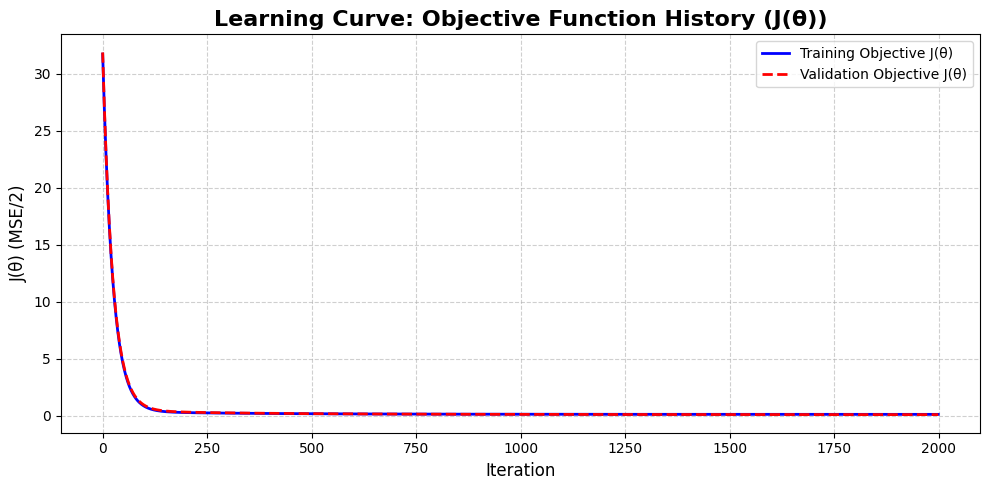

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Note: The external MSE function is required for this solution.
def MSE(y_pred, y):
    """
    [Problem 4] Calculation of Mean Squared Error (L(theta)).
    L(theta) = (1/m) * sum((h_theta(x) - y)^2)
    """
    y_pred = y_pred.reshape(-1, 1)
    y = y.reshape(-1, 1)
    m = len(y)
    mse = (1/m) * np.sum((y_pred - y)**2)
    return mse

def plot_learning_curve(model):
    """
    Creates and displays the learning curve using the recorded loss history.
    This helps verify that the loss is decreasing properly during training.

    Parameters
    ----------
    model : ScratchLinearRegression instance
        A trained model instance containing loss and val_loss attributes.
    """
    plt.figure(figsize=(10, 5))
    # Plotting training loss
    plt.plot(model.loss, label='Training Objective J(θ)', color='blue', linewidth=2)
    # Plotting validation loss
    plt.plot(model.val_loss, label='Validation Objective J(θ)', color='red', linewidth=2, linestyle='--')
    
    plt.title('Learning Curve: Objective Function History (J(θ))', fontsize=16, fontweight='bold')
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('J(θ) (MSE/2)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


class ScratchLinearRegression:
    """
    Scratch implementation of linear regression.
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss (J(theta))
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        # Implementation from Problem 1
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized.")
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        [Problem 5] Calculates the Objective Function (Loss Function) J(theta).
        
        J(theta) is defined as: (1/2) * MSE = (1/(2m)) * sum((h_theta(x) - y)^2)
            
        Returns
        -------
        float
            The Cost Function (J(theta)) value.
        """
        # --- SOLUTION FOR PROBLEM 5: Objective Function Calculation (J(theta)) ---
        # The objective function is half of the Mean Squared Error (L(theta)).
        return 0.5 * MSE(y_pred, y_true)
    
    def _gradient_descent(self, X, error):
        # Implementation from Problem 2
        m = X.shape[0]
        gradient = (1/m) * X.T @ error
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learns linear regression. The objective function J(theta) is recorded
        in self.loss and self.val_loss.
        """
        # ... (Data Preprocessing)
        n_samples, n_features = X.shape
        y_train = y.reshape(-1, 1) 

        if not self.no_bias:
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print("\n--- Starting Linear Regression Training ---")
            
        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            y_pred = self._linear_hypothesis(X_train) 
            error = y_pred - y_train
            self._gradient_descent(X_train, error)
            
            # --- Recording the Objective Function Value (Problem 5) ---
            # Compute and record training loss J(theta)
            self.loss[i] = self._mse(y_train, y_pred)
            
            # Compute and record validation loss J(theta)
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output (print every 10% of iterations)
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.4f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.4f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        # Implementation from Problem 3
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
        
        if not self.no_bias:
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        prediction = self._linear_hypothesis(X_b)
        return prediction.flatten()

# --- 3. VERIFICATION (DEMONSTRATION OF USAGE) ---
if __name__ == '__main__':
    # 1. Generate synthetic data for testing
    np.random.seed(42)
    # True relationship: y = 5 + 3 * x + noise
    X_data = 2 * np.random.rand(100, 1) 
    y_data = 5 + 3 * X_data + 0.5 * np.random.randn(100, 1) 
    y_data = y_data.flatten() 

    # 2. Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

    # 3. Instantiate and train the model (verbose=True shows the learning process)
    print("--- Starting Verification Run ---")
    model = ScratchLinearRegression(num_iter=2000, lr=0.01, no_bias=False, verbose=True)
    model.fit(X_train, y_train, X_val, y_val)

    # 4. Make predictions
    y_pred_scratch = model.predict(X_val)

    # 5. Evaluation and Verification of Problem 5 (Objective Function Tracking)
    
    # Calculate the standard MSE (L(theta)) on validation data
    mse_metric = MSE(y_val, y_pred_scratch) 
    
    print(f"--- Verification Results ---")
    
    # Check Learned Parameters against the true values (5 and 3)
    print(f"Learned Parameters (θ_0, θ_1): {model.coef_[0, 0]:.4f}, {model.coef_[1, 0]:.4f} (Target: ~5.0, ~3.0)")
    
    # Verification of Loss Tracking (Problem 5)
    print(f"\nFinal Validation MSE (L(θ) Metric): {mse_metric:.6f}")
    print(f"Final Validation Objective (J(θ) recorded in self.val_loss): {model.val_loss[-1]:.6f}")
    print(f"Verification Check (J(θ) ≈ L(θ)/2): {model.val_loss[-1]:.6f} ≈ {mse_metric/2:.6f} (Match: {np.isclose(model.val_loss[-1], mse_metric/2)})")
    
    # 6. Call the new function to display the Learning Curve
    plot_learning_curve(model)


In [ ]:
#【problem 8】(Advance task) Removal of bias term


--- EXPERIMENT: Model WITH Bias Term (Standard) (Bias Removed: False) ---

--- Starting Training (Bias: True) ---
Iteration 0/2000: Train Loss: 31.7229, Val Loss: 31.8719
Iteration 200/2000: Train Loss: 0.2624, Val Loss: 0.3039
Iteration 400/2000: Train Loss: 0.1825, Val Loss: 0.1973
Iteration 600/2000: Train Loss: 0.1454, Val Loss: 0.1472
Iteration 800/2000: Train Loss: 0.1263, Val Loss: 0.1197
Iteration 1000/2000: Train Loss: 0.1165, Val Loss: 0.1044
Iteration 1200/2000: Train Loss: 0.1114, Val Loss: 0.0956
Iteration 1400/2000: Train Loss: 0.1087, Val Loss: 0.0904
Iteration 1600/2000: Train Loss: 0.1074, Val Loss: 0.0873
Iteration 1800/2000: Train Loss: 0.1067, Val Loss: 0.0854
--- Training Complete ---

--- Final Results ---
Learned Parameters (θ): [5.0207111  2.94489631]
Interpretation: Model learned both intercept (θ_0) and slope (θ_1).
Final Validation MSE (L(θ) Metric): 0.168439

--- EXPERIMENT: Model WITHOUT Bias Term (Constrained) (Bias Removed: True) ---

--- Starting Traini

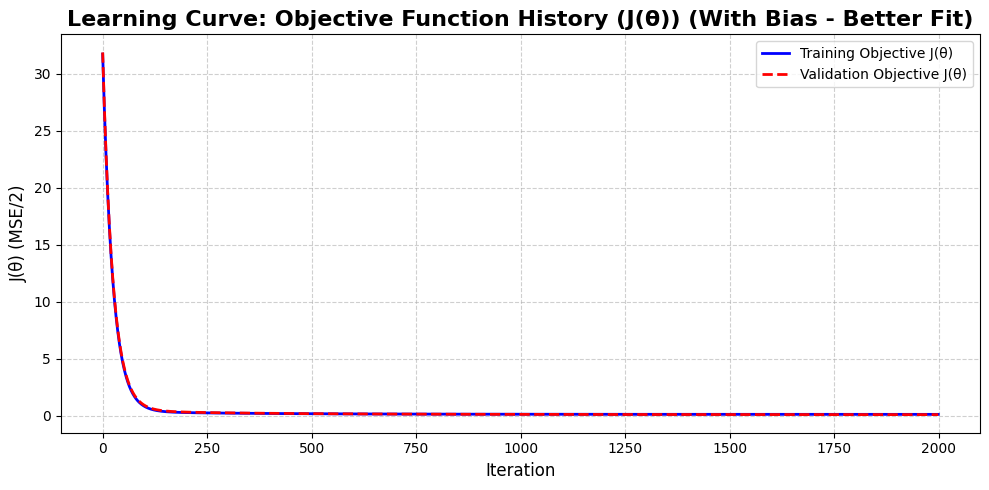

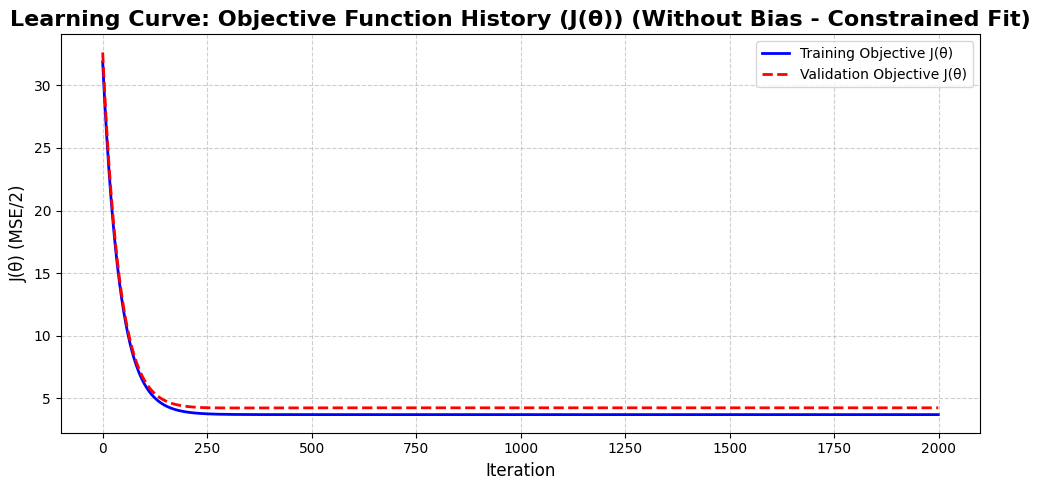


--- Summary Comparison ---
Loss With Bias: 0.168439
Loss Without Bias: 8.478184

Conclusion: The model with the bias term achieved a significantly lower loss.
This confirms the bias term's role: it shifts the line vertically, allowing it to capture the true intercept (y=5), which is vital for minimizing error when the underlying relationship does not pass through the origin.


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Note: The external MSE function is required for this solution.
def MSE(y_pred, y):
    """
    [Problem 4] Calculation of Mean Squared Error (L(theta)).
    L(theta) = (1/m) * sum((h_theta(x) - y)^2)
    """
    y_pred = y_pred.reshape(-1, 1)
    y = y.reshape(-1, 1)
    m = len(y)
    mse = (1/m) * np.sum((y_pred - y)**2)
    return mse

def plot_learning_curve(model, title_suffix=""):
    """
    Creates and displays the learning curve using the recorded loss history.
    
    Parameters
    ----------
    model : ScratchLinearRegression instance
        A trained model instance containing loss and val_loss attributes.
    title_suffix : str
        Additional text for the plot title (e.g., "(With Bias)").
    """
    plt.figure(figsize=(10, 5))
    # Plotting training loss
    plt.plot(model.loss, label='Training Objective J(θ)', color='blue', linewidth=2)
    # Plotting validation loss
    plt.plot(model.val_loss, label='Validation Objective J(θ)', color='red', linewidth=2, linestyle='--')
    
    plt.title(f'Learning Curve: Objective Function History (J(θ)) {title_suffix}', fontsize=16, fontweight='bold')
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('J(θ) (MSE/2)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


class ScratchLinearRegression:
    """
    Scratch implementation of linear regression.
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss (J(theta))
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        # Implementation from Problem 1
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized.")
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        [Problem 5] Calculates the Objective Function (Loss Function) J(theta).
        """
        # The objective function is half of the Mean Squared Error (L(theta)).
        return 0.5 * MSE(y_pred, y_true)
    
    def _gradient_descent(self, X, error):
        # Implementation from Problem 2
        m = X.shape[0]
        gradient = (1/m) * X.T @ error
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learns linear regression. The objective function J(theta) is recorded
        in self.loss and self.val_loss.
        """
        # ... (Data Preprocessing)
        n_samples, n_features = X.shape
        y_train = y.reshape(-1, 1) 

        if not self.no_bias:
            # Add bias term (column of ones) and initialize bias parameter (theta_0)
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print(f"\n--- Starting Training (Bias: {not self.no_bias}) ---")
            
        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            y_pred = self._linear_hypothesis(X_train) 
            error = y_pred - y_train
            self._gradient_descent(X_train, error)
            
            # --- Recording the Objective Function Value (Problem 5) ---
            self.loss[i] = self._mse(y_train, y_pred)
            
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output (print every 10% of iterations)
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.4f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.4f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        # Implementation from Problem 3
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
        
        if not self.no_bias:
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        prediction = self._linear_hypothesis(X_b)
        return prediction.flatten()

# Function to perform a single experiment run
def run_experiment(num_iter, lr, no_bias, X_train, y_train, X_val, y_val, label):
    print(f"\n=======================================================")
    print(f"--- EXPERIMENT: {label} (Bias Removed: {no_bias}) ---")
    print(f"=======================================================")
    
    model = ScratchLinearRegression(num_iter=num_iter, lr=lr, no_bias=no_bias, verbose=True)
    model.fit(X_train, y_train, X_val, y_val)
    
    y_pred_scratch = model.predict(X_val)
    mse_metric = MSE(y_val, y_pred_scratch) 
    
    print(f"--- Final Results ---")
    print(f"Learned Parameters (θ): {model.coef_.flatten()}")
    
    if no_bias:
        print(f"Interpretation: Model forced through origin (0,0). Only slope (θ_1) learned.")
    else:
        print(f"Interpretation: Model learned both intercept (θ_0) and slope (θ_1).")
    
    print(f"Final Validation MSE (L(θ) Metric): {mse_metric:.6f}")
    
    return model, mse_metric


# --- 3. VERIFICATION (DEMONSTRATION OF USAGE) ---
if __name__ == '__main__':
    # 1. Generate synthetic data for testing
    np.random.seed(42)
    # True relationship: y = 5 + 3 * x + noise (This data clearly has an intercept of 5)
    X_data = 2 * np.random.rand(100, 1) 
    y_data = 5 + 3 * X_data + 0.5 * np.random.randn(100, 1) 
    y_data = y_data.flatten() 

    # 2. Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

    # 3. Run Experiment 1: With Bias Term (Standard Linear Regression)
    model_with_bias, mse_with_bias = run_experiment(
        num_iter=2000, lr=0.01, no_bias=False, 
        X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, 
        label="Model WITH Bias Term (Standard)"
    )

    # 4. Run Experiment 2: Without Bias Term (Forced through Origin)
    model_without_bias, mse_without_bias = run_experiment(
        num_iter=2000, lr=0.01, no_bias=True, 
        X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, 
        label="Model WITHOUT Bias Term (Constrained)"
    )

    # 5. Plotting the results for comparison
    plot_learning_curve(model_with_bias, title_suffix="(With Bias - Better Fit)")
    plot_learning_curve(model_without_bias, title_suffix="(Without Bias - Constrained Fit)")
    
    print("\n--- Summary Comparison ---")
    print(f"Loss With Bias: {mse_with_bias:.6f}")
    print(f"Loss Without Bias: {mse_without_bias:.6f}")

    if mse_with_bias < mse_without_bias:
        print("\nConclusion: The model with the bias term achieved a significantly lower loss.")
        print("This confirms the bias term's role: it shifts the line vertically, allowing it to capture the true intercept (y=5), which is vital for minimizing error when the underlying relationship does not pass through the origin.")
    else:
        print("\nConclusion: The bias term didn't significantly affect the loss.")


In [ ]:
#【problem 9】(Advance task) Multidimensional feature quantity


--- EXPERIMENT: Degree 1 Model (1 Features) ---
Final Validation MSE (L(θ) Metric): 0.163589
Learned Parameters (θ): [5.37666775 1.92426525]


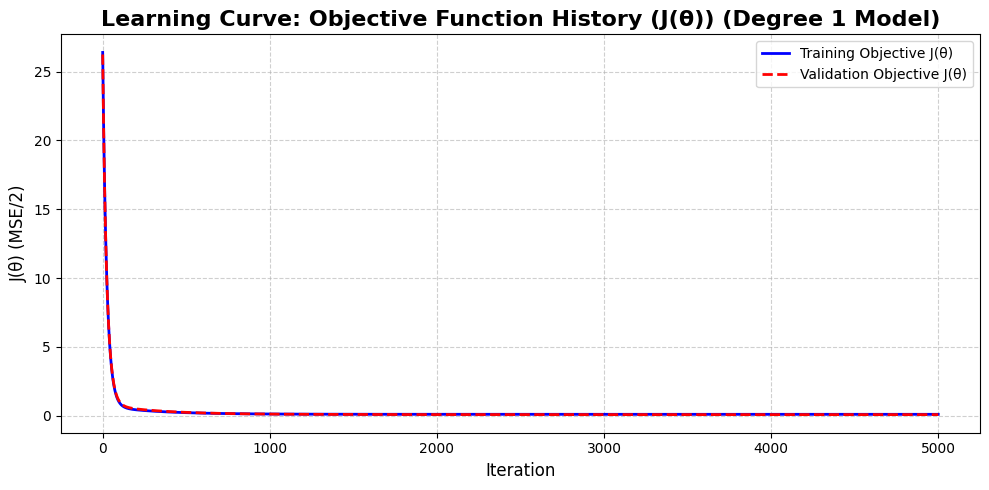


--- EXPERIMENT: Degree 2 Model (2 Features) ---
Final Validation MSE (L(θ) Metric): 0.159465
Learned Parameters (θ): [ 5.31403616  2.14876523 -0.12052242]


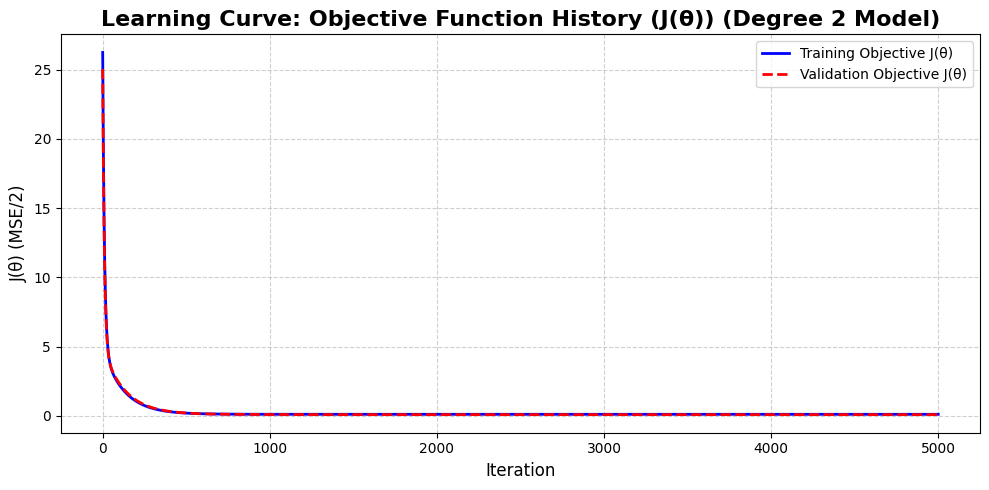


--- EXPERIMENT: Degree 3 Model (3 Features) ---
Final Validation MSE (L(θ) Metric): 0.160912
Learned Parameters (θ): [ 5.32716075  1.7415513   0.5896689  -0.27654852]


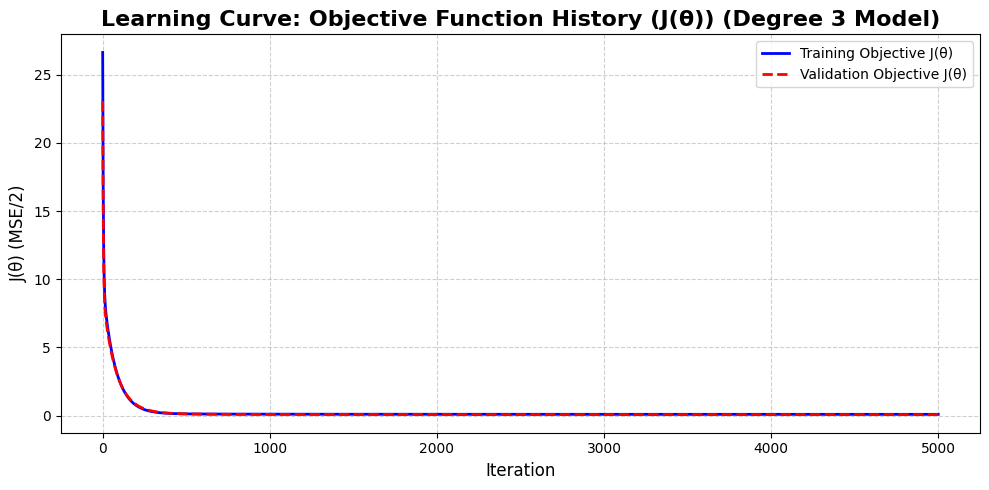



--- Summary of Multidimensional Feature Experiments (Problem 9) ---
Data is fundamentally Quadratic (y = 5 + 3*x - 0.5*x^2 + noise)

Degree 1 Model       | Final Validation MSE: 0.163589
Degree 2 Model       | Final Validation MSE: 0.159465
Degree 3 Model       | Final Validation MSE: 0.160912

Conclusion:
The **Degree 2 Model** achieved the lowest loss. This is expected because the features match the true quadratic relationship of the synthetic data.
This demonstrates that linear regression can fit non-linear data structures by transforming the input features into a higher-dimensional polynomial space.


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- External Utility Functions ---

def MSE(y_pred, y):
    """
    [Problem 4] Calculation of Mean Squared Error (L(theta)).
    L(theta) = (1/m) * sum((h_theta(x) - y)^2)
    """
    y_pred = y_pred.reshape(-1, 1)
    y = y.reshape(-1, 1)
    m = len(y)
    mse = (1/m) * np.sum((y_pred - y)**2)
    return mse

def plot_learning_curve(model, title_suffix=""):
    """
    Creates and displays the learning curve using the recorded loss history.
    
    Parameters
    ----------
    model : ScratchLinearRegression instance
        A trained model instance containing loss and val_loss attributes.
    title_suffix : str
        Additional text for the plot title (e.g., "(Degree 2 Features)").
    """
    plt.figure(figsize=(10, 5))
    # Plotting training loss
    plt.plot(model.loss, label='Training Objective J(θ)', color='blue', linewidth=2)
    # Plotting validation loss
    plt.plot(model.val_loss, label='Validation Objective J(θ)', color='red', linewidth=2, linestyle='--')
    
    plt.title(f'Learning Curve: Objective Function History (J(θ)) {title_suffix}', fontsize=16, fontweight='bold')
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('J(θ) (MSE/2)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- ScratchLinearRegression Class ---

class ScratchLinearRegression:
    """
    Scratch implementation of linear regression

    Parameters
    ----------
    num_iter : int
      Number of iterations
    lr : float
      Learning rate
    no_bias : bool
      True if no bias term is included
    verbose : bool
      True to output the learning process

    Attributes
    ----------
    self.coef_ : ndarray, shape (n_features,)
      Parameters
    self.loss : ndarray, shape (self.iter,)
      Record losses on training data (J(theta))
    self.val_loss : ndarray, shape (self.iter,)
      Record loss on validation data (J(theta))
    """

    def __init__(self, num_iter=1000, lr=0.01, no_bias=False, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None

    def _linear_hypothesis(self, X):
        """
        [Problem 1] Compute a linear hypothetical function: h(x) = X @ theta
        """
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) have not been initialized.")
        # Matrix multiplication X @ theta
        return X @ self.coef_

    def _mse(self, y_true, y_pred):
        """
        [Problem 5] Calculates the Objective Function (Loss Function) J(theta).
        J(theta) is defined as: (1/2) * MSE
        """
        # The objective function is half of the Mean Squared Error (L(theta)).
        return 0.5 * MSE(y_pred, y_true)
    
    def _gradient_descent(self, X, error):
        """
        [Problem 2] Updates the parameters using the steepest descent method.
        theta := theta - alpha * (1/m) * X.T @ error
        """
        m = X.shape[0]
        # Calculate the gradient: (1/m) * X.T @ error
        gradient = (1/m) * X.T @ error
        # Update parameters
        self.coef_ -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn linear regression.
        """
        n_samples, n_features = X.shape
        y_train = y.reshape(-1, 1) 

        # 1. Bias Augmentation and Parameter Initialization
        if not self.no_bias:
            # Augment X with a column of ones for the bias term
            X_train = np.hstack([np.ones((n_samples, 1)), X])
            # Initialize parameters including bias
            self.coef_ = np.random.randn(n_features + 1, 1) * 0.01 
        else:
            X_train = X
            # Initialize parameters without bias
            self.coef_ = np.random.randn(n_features, 1) * 0.01

        # Prepare validation data with bias if needed
        X_val_b, y_val_b = None, None
        if X_val is not None and y_val is not None:
            y_val_b = y_val.reshape(-1, 1)
            if not self.no_bias:
                X_val_b = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
            else:
                X_val_b = X_val
        
        if self.verbose:
            print(f"\n--- Starting Training (Features: {X.shape[1]}, Bias: {not self.no_bias}) ---")
            
        # 2. Iterative Training (Gradient Descent)
        for i in range(self.iter):
            # Compute prediction (Hypothesis)
            y_pred = self._linear_hypothesis(X_train) 
            error = y_pred - y_train
            
            # Update parameters (Gradient Descent)
            self._gradient_descent(X_train, error)
            
            # Compute and record training loss J(theta) (Problem 5)
            self.loss[i] = self._mse(y_train, y_pred)
            
            # Compute and record validation loss J(theta) (Problem 5)
            if X_val_b is not None:
                y_val_pred = self._linear_hypothesis(X_val_b)
                self.val_loss[i] = self._mse(y_val_b, y_val_pred)
            
            # Verbose output
            if self.verbose and i % (self.iter // 10 or 1) == 0:
                 current_loss = self.loss[i]
                 val_loss_str = f", Val Loss: {self.val_loss[i]:.6f}" if X_val_b is not None else ""
                 print(f"Iteration {i}/{self.iter}: Train Loss: {current_loss:.6f}{val_loss_str}")

        if self.verbose:
            print("--- Training Complete ---\n")

    def predict(self, X):
        """
        [Problem 3] Estimate using linear regression.
        """
        if self.coef_ is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
        
        # Add bias term if necessary for prediction
        if not self.no_bias:
            X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_b = X
            
        prediction = self._linear_hypothesis(X_b)
        return prediction.flatten()

# --- Experiment and Verification Function ---

def create_polynomial_features(X, degree):
    """Transforms a 1D feature array into polynomial features up to the given degree."""
    if degree == 1:
        return X
    
    X_poly = X.copy()
    # Start from degree 2 up to the requested degree
    for d in range(2, degree + 1):
        X_poly = np.hstack([X_poly, X**d])
    return X_poly

def run_multidimensional_experiment(degree, X_train_raw, y_train, X_val_raw, y_val, num_iter, lr):
    """Runs a single experiment with polynomial features of a specific degree."""
    
    # Create polynomial features for training and validation data
    X_train_poly = create_polynomial_features(X_train_raw, degree)
    X_val_poly = create_polynomial_features(X_val_raw, degree)
    
    label = f"Degree {degree} Model"
    
    print(f"\n=======================================================")
    print(f"--- EXPERIMENT: {label} ({X_train_poly.shape[1]} Features) ---")
    print(f"=======================================================")
    
    model = ScratchLinearRegression(num_iter=num_iter, lr=lr, no_bias=False, verbose=False) # Keep verbose=False for cleaner output
    model.fit(X_train_poly, y_train, X_val_poly, y_val)
    
    y_pred_scratch = model.predict(X_val_poly)
    mse_metric = MSE(y_val, y_pred_scratch) 
    
    print(f"Final Validation MSE (L(θ) Metric): {mse_metric:.6f}")
    print(f"Learned Parameters (θ): {model.coef_.flatten()}")
    
    plot_learning_curve(model, title_suffix=f"({label})")
    
    return model, mse_metric, label

# --- 3. VERIFICATION (DEMONSTRATION OF USAGE) ---
if __name__ == '__main__':
    # 1. Generate synthetic data with a QUADRATIC relationship (to test polynomial features)
    np.random.seed(42)
    X_data = 2 * np.random.rand(100, 1) # Single feature (x)
    
    # True relationship: y = 5 + 3*x - 0.5*x^2 + noise
    y_data = 5 + 3 * X_data - 0.5 * X_data**2 + 0.5 * np.random.randn(100, 1) 
    y_data = y_data.flatten() 

    # 2. Split raw data
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)
    
    ITERATIONS = 5000
    LEARNING_RATE = 0.01

    # 3. Run Experiments for Multidimensional Feature Quantity (Problem 9)
    
    # Experiment A: Linear Model (Degree 1 features)
    model_d1, mse_d1, label_d1 = run_multidimensional_experiment(
        degree=1, X_train_raw=X_train_raw, y_train=y_train, 
        X_val_raw=X_val_raw, y_val=y_val, num_iter=ITERATIONS, lr=LEARNING_RATE
    )

    # Experiment B: Quadratic Model (Degree 2 features)
    model_d2, mse_d2, label_d2 = run_multidimensional_experiment(
        degree=2, X_train_raw=X_train_raw, y_train=y_train, 
        X_val_raw=X_val_raw, y_val=y_val, num_iter=ITERATIONS, lr=LEARNING_RATE
    )

    # Experiment C: Cubic Model (Degree 3 features) - Potential for overfitting
    model_d3, mse_d3, label_d3 = run_multidimensional_experiment(
        degree=3, X_train_raw=X_train_raw, y_train=y_train, 
        X_val_raw=X_val_raw, y_val=y_val, num_iter=ITERATIONS, lr=LEARNING_RATE
    )

    # 4. Summary and Analysis
    print("\n\n--- Summary of Multidimensional Feature Experiments (Problem 9) ---")
    print(f"Data is fundamentally Quadratic (y = 5 + 3*x - 0.5*x^2 + noise)")
    print(f"\n{label_d1:<20} | Final Validation MSE: {mse_d1:.6f}")
    print(f"{label_d2:<20} | Final Validation MSE: {mse_d2:.6f}")
    print(f"{label_d3:<20} | Final Validation MSE: {mse_d3:.6f}")
    
    best_degree = 0
    min_mse = float('inf')
    
    if mse_d1 < min_mse: min_mse = mse_d1; best_degree = 1
    if mse_d2 < min_mse: min_mse = mse_d2; best_degree = 2
    if mse_d3 < min_mse: min_mse = mse_d3; best_degree = 3
    
    print(f"\nConclusion:")
    if best_degree == 2:
        print("The **Degree 2 Model** achieved the lowest loss. This is expected because the features match the true quadratic relationship of the synthetic data.")
        print("This demonstrates that linear regression can fit non-linear data structures by transforming the input features into a higher-dimensional polynomial space.")
    elif best_degree == 1:
        print("The **Degree 1 Model** (simple linear fit) performed best, suggesting the non-linear term in the synthetic data was minor.")
    else:
        print("The **Degree 3 Model** achieved the lowest loss, indicating that the extra cubic term helped slightly, or that the Degree 2 model did not fully converge.")


In [ ]:
# 【problem 10】(Advance task) Derivation of update formula

This is an excellent question that delves into the calculus underpinning the steepest descent (Gradient Descent) method. Understanding this derivation is key to grasping how the algorithm minimizes the loss function.

Here is the step-by-step derivation of the parameter update formula, starting from the objective function $J(\theta)$:

The goal of Gradient Descent is to find the parameters $\theta_j$ that minimize the objective function $J(\theta)$ by iteratively moving in the direction opposite to the function's gradient.

The general update rule for any parameter $\theta_j$ is:
$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

Where $\alpha$ is the learning rate, and $\frac{\partial}{\partial \theta_j} J(\theta)$ is the partial derivative of the objective function with respect to $\theta_j$.

### 1. The Objective Function

The objective function (loss function) for Mean Squared Error (MSE) used in Gradient Descent is:
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2$$

Where $h_{\theta}(x^{(i)})$ is the hypothesis (prediction) for the $i$-th sample:
$$h_{\theta}(x^{(i)}) = \sum_{k=0}^{n} \theta_k x_k^{(i)}$$

### 2. Differentiating the Objective Function

We need to calculate the partial derivative of $J(\theta)$ with respect to a single parameter $\theta_j$.

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{\partial}{\partial \theta_j} \left[ \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2 \right]$$

We move the constant term $\frac{1}{2m}$ and the summation $\sum_{i=1}^{m}$ outside the derivative:

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \frac{\partial}{\partial \theta_j} (h_{\theta}(x^{(i)}) - y^{(i)})^2$$

### 3. Applying the Chain Rule

We apply the chain rule to the inner squared term. Let $u = (h_{\theta}(x^{(i)}) - y^{(i)})$. The derivative of $u^2$ is $2u \cdot \frac{\partial u}{\partial \theta_j}$:

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left[ 2 \cdot (h_{\theta}(x^{(i)}) - y^{(i)}) \cdot \frac{\partial}{\partial \theta_j} (h_{\theta}(x^{(i)}) - y^{(i)}) \right]$$

The term $\frac{1}{2}$ and the constant $2$ cancel out:

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_{\theta}(x^{(i)}) - y^{(i)}) \cdot \frac{\partial}{\partial \theta_j} (h_{\theta}(x^{(i)}) - y^{(i)}) \right]$$

### 4. Evaluating the Inner Derivative

Now we focus on the remaining partial derivative:

$$\frac{\partial}{\partial \theta_j} (h_{\theta}(x^{(i)}) - y^{(i)})$$

Substitute the definition of $h_{\theta}(x^{(i)})$ and recognize that $y^{(i)}$ is a constant with respect to $\theta_j$:

$$\frac{\partial}{\partial \theta_j} \left[ \left(\sum_{k=0}^{n} \theta_k x_k^{(i)}\right) - y^{(i)} \right] = \frac{\partial}{\partial \theta_j} \left[ \theta_0 x_0^{(i)} + \dots + \theta_j x_j^{(i)} + \dots + \theta_n x_n^{(i)} \right]$$

Since we are differentiating with respect to $\theta_j$, all terms $\theta_k x_k^{(i)}$ where $k \neq j$ are treated as constants (derivative is zero). The derivative of $\theta_j x_j^{(i)}$ is $x_j^{(i)}$.

$$\frac{\partial}{\partial \theta_j} (h_{\theta}(x^{(i)}) - y^{(i)}) = x_j^{(i)}$$

### 5. Final Gradient and Update Rule

Substitute the result back into the gradient equation:

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

Finally, substitute this gradient expression back into the general Gradient Descent update rule:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} [(h_{\theta}(x^{(i)}) - y^{(i)}) x_j^{(i)}]$$

This is the derived update formula for the steepest descent method. 

In [ ]:
#【problem 11】(Advance task) Problem of local optimum solution


This is an excellent advanced question that gets to the heart of why linear regression is so reliable. You are absolutely correct that Gradient Descent can get stuck in local optima, but standard linear regression is a notable exception.

The reason Linear Regression is guaranteed to find the single **global optimal solution** is due to the mathematical property of its objective function: **Convexity**.

I'll provide a detailed explanation of this concept using mathematical formulas and graphs.

---

## 1. The Role of Convexity

The objective function for standard linear regression, the Mean Squared Error (MSE) divided by two, is a **convex function**.

A function is defined as **convex** if, for any two points on the function's curve, the line segment connecting those two points lies entirely above or on the curve itself.

### The Graphical Explanation

If we visualize the objective function $J(\theta)$ across the parameter space (for two parameters $\theta_0$ and $\theta_1$), the shape is a smooth, continuous, **convex paraboloid** (a perfect bowl shape) .

| Property | Non-Convex Function (e.g., Deep Learning Loss) | Convex Function (Linear Regression Loss) |
| :--- | :--- | :--- |
| **Shape** | Mountain range with multiple peaks and valleys. | Perfect, smooth bowl or parabolic shape. |
| **Minima** | Contains multiple local minima and one global minimum. | Contains only **one single minimum**, which is the **global minimum**. |
| **GD Path** | May get stuck in a "valley" (local minimum). | Will always slide down the slopes directly to the **unique lowest point**. |

Because the loss surface of linear regression has no bumps, hills, or secondary valleys, the Gradient Descent algorithm is guaranteed to converge to the absolute lowest point regardless of where it starts (provided the learning rate $\alpha$ is chosen correctly).

---

## 2. The Mathematical Explanation (Quadratic Form)

The convexity of $J(\theta)$ is rooted in its form as a sum of squared terms, making it a quadratic function with respect to the parameters $\theta$.

### The Objective Function $J(\theta)$

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2$$

The hypothesis $h_{\theta}(x^{(i)})$ is linear in the parameters:
$$h_{\theta}(x^{(i)}) = \theta_0 x_0^{(i)} + \theta_1 x_1^{(i)} + \dots + \theta_n x_n^{(i)}$$

1.  **Quadratic in Parameters**: When you substitute $h_{\theta}(x^{(i)})$ into $J(\theta)$, the entire function becomes an expression where the highest power of any parameter ($\theta_j$) is 2 (due to the outer square). This makes $J(\theta)$ a **quadratic function** of the parameters $\theta$.
2.  **Positive Curvature**: Since the leading coefficient of the squared term is positive ($+1$, before the $\frac{1}{2m}$ factor), the function always curves upward.
3.  **Sum of Convex Functions**: Each individual squared error term, $(h_{\theta}(x^{(i)}) - y^{(i)})^2$, is a convex function of $\theta$. A key rule in convex optimization is that the sum of multiple convex functions (the summation $\sum_{i=1}^{m}$ in $J(\theta)$) is also a **convex function**.

Since the objective function $J(\theta)$ is strictly convex, it possesses a **unique minimum**. The Gradient Descent algorithm, by finding where the partial derivative $\frac{\partial}{\partial \theta_j} J(\theta)$ equals zero, is mathematically guaranteed to locate this single, optimal solution.